# PCI on Pearl's Desert Traveller

This notebook works Pearl's desert-traveller puzzle with PCI (probabilistic causal
impacts), the responsibility framework of the companion paper. For each candidate cause
PCI reports three numbers in $[0,1]$: a necessity score, a sufficiency score, and their
joint combination. The puzzle is a standard stress test, because classical accounts of
actual causation find it hard.

## Neither enemy is necessary, yet the traveller died

A traveller has two enemies who act independently. One poisons the water; the other
later shoots a hole in the canteen so it drains. The traveller sets off and dies. Who
caused the death?

The difficulty is overdetermination via preemption. Each act would have killed on its
own, so neither looks necessary: take away the poisoner and the empty canteen still
kills, take away the shooter and the cyanide still kills. A but-for test therefore
clears both suspects, which is plainly wrong, since the traveller died of something.
Only one mechanism actually operated. If the traveller drank before the canteen drained, cyanide killed him and preempted the
dehydration path; if the canteen drained first, dehydration killed him and the poison
never got its chance. A good account has to finger
the mechanism that operated, leave the dormant enemy some share of the blame, and
degrade gracefully when a mechanism is unreliable.

## PCI grades what Pearl makes binary

Pearl's probability of actual causation returns a binary verdict per noise state, full
blame or none. PCI returns a graded score. This notebook shows that PCI agrees with
Pearl's ranking in every scenario, that it leaves the dormant cause a small non-zero
share, and that its scores separate two scenarios Pearl's verdict cannot tell apart.

We work the deterministic case first, then a weak-poison variant. Each example runs
twice, once through the framework's `ThinSearchSampler` and once through a hand-rolled
enumeration. Agreement between them is evidence that the framework computes what we
claim.

## Two enemies, one traveller

- Shooter ($X$) empties the canteen ($X=1$ when they act).
- Poisoner ($P$) puts cyanide in the canteen ($P=1$ when they act).

A single coin $u$ decides the order:

- $u = 0$: the traveller drank the poisoned water before the shooter emptied the
  canteen, so cyanide killed.
- $u = 1$: the canteen was empty before the traveller could drink, so dehydration
  killed.

Both enemies acted ($X = P = 1$) and the traveller died ($Y = 1$). PCI's question is how
much responsibility each enemy bears.

Two indicators record which path operated: $c$ for the cyanide path (poisoned water was
drunk) and $d$ for the dehydration path (drank from an empty canteen). Factually
$c = 1, d = 0$ in Scenario A, and $c = 0, d = 1$ in Scenario B.

The weak-poison variant adds a fatality coin $\xi \sim \mathrm{Bern}(\alpha)$ with
$\alpha = 0.1$: drinking the cyanide kills only when $\xi$ fires. A new mediator
$v_C = c \cdot \xi$ records that the cyanide was fatal.

## The components of PCI

A PCI computation has the following moving parts (sec3:451--488):

| Component | Role | Choice in this notebook |
|---|---|---|
| Suspect set $\mathbf{S}$ | the pool of variables that could plausibly be causes | $\{X, P\}$ |
| Candidate cause sets $\mathbf{C}$ | the subsets of $\mathbf{S}$ PCI interrogates, weighted by $\Gamma$ | singletons $\{X\}$, $\{P\}$ |
| Witness pool $\mathbf{W}$ | context variables that *may* be held fixed | mediators $\{c, d\}$ (basic), $\{c, d, v_C\}$ (weak) |
| Active witness sets $\mathbf{T} \subseteq \mathbf{W}$ | the subset of witnesses pinned in a given pass; weighted by $\Gamma$ | all subsets, cardinality-uniform $\Gamma$ |
| Alternative-value distribution $\Delta$ | supplies the counterfactual value the cause is set to | deterministic $1 \to 0$ |
| Noise distribution $P_{\mathbf{U}}$ | fixes the noise realisations the average runs over | forensic posterior (point mass at the scenario's noise realisation) |
| Non-cause variables (suspects not in $\mathbf{C}$, mediators not in $\mathbf{T}$) | follow the SCM under the sampled noise; *not* hard-coded | drawn from priors / computed from the SCM |

## Three expectations per cause
For a candidate cause $C$:

- *Necessity*, $N_C$, asks: if $C$ had not acted, how often would the
  traveller have survived? High when removing $C$ tends to undo the death.
- *Sufficiency*, $S_C$, asks: with $C$ acting as it factually did, how often
  is the death still produced? High when $C$ on its own reliably brings
  about the outcome.
- *Joint*, $J_C$, rewards $C$ only when *both* hold in the same draw: removing
  $C$ flips the outcome *and* keeping $C$ sustains it. $J_C$ is the number the
  verdicts below are read off.

For each candidate cause $C$ and the factual outcome $y^\star = 1$, PCI's
three quantities are expectations averaging jointly over $\Gamma$
(witness subsets), $\Delta$ (alternative cause values), $P_{\mathbf{U}}$
(noise), and the SCM-driven distribution of non-cause variables. In
compact form:

$$
\begin{aligned}
N_C &= \mathbb{E}_{\Gamma, \Delta, P_{\mathbf{U}}, \text{SCM}} \bigl[\, \mathbb{1}\{Y^n \neq y^\star\} \,\bigr],\\
S_C &= \mathbb{E}_{\Gamma, P_{\mathbf{U}}, \text{SCM}} \bigl[\, \mathbb{1}\{Y^s = y^\star\} \,\bigr],\\
J_C &= \mathbb{E}_{\Gamma, \Delta, P_{\mathbf{U}}, \text{SCM}} \bigl[\, \mathbb{1}\{Y^n \neq y^\star\}\,\mathbb{1}\{Y^s = y^\star\} \,\bigr].
\end{aligned}
$$

Where $Y^n$ is the outcome under the *necessity world* ($\mathrm{do}(C = c')$ with
$c' \sim \Delta$, witnesses in $T$ pinned at factual) and $Y^s$ is the
outcome under the *sufficiency world* ($\mathrm{do}(C = c^\star)$, witnesses in
$T$ pinned at factual). All three are in $[0, 1]$; higher = more attribution.

Each random draw in the expectation is:

1. Sample noise $\mathbf{u} \sim P_{\mathbf{U}}$ (forensic posterior or prior).
2. Sample a witness subset $T \subseteq \mathbf{W}$ from $\Gamma$ (cardinality-uniform here).
3. Sample an alternative value $c' \sim \Delta$ (deterministic flip here).
4. Compute $Y^n$ and $Y^s$ from the SCM with the indicated interventions;
   the SCM trace samples any non-cause suspect that is neither in $\mathbf{C}$
   nor in $\mathbf{T}$ from its prior.
5. Evaluate the indicator on the (binary) outcome.

Necessity counts how often removing $C$ flips $Y$, and sufficiency how often keeping
$C$ at factual sustains it. Both readings hold only if you remember that the averaging
runs over all five sources of randomness above. We integrate the
non-cause suspect out in particular, giving its factual value no special weight, so
necessity and sufficiency average across a population of related counterfactual
settings.

## Pinning the noise to the forensic scenario

PCI's integration averages over $P_{\mathbf{U}}$, and different questions call for
different choices. We build one pyro model per scenario, with the noise pinned at that
scenario's forensic realisation. `ThinSearchSampler` runs separately on
each model with `batch_size = 1`. The forensic noise is upstream of the outcome $Y$ in the SCM: we observe mediator-level
evidence, post-mortem cyanide detection and temporal evidence, and pin the noise
accordingly. We never condition on $Y$ itself.

The paper rules out the alternative ("fully conditional") of
conditioning on $Y$ as a downstream-conditioning anti-pattern
(sec3:330--336, sec3:381--387).

## 1. Setup

We import the PCI framework (`pci.explanation`), Pyro for the structural
models, and the usual numerical stack. The `smoke_test` flag (set in CI) only
shrinks sample counts; it does not change any reported logic.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pyro
import pyro.distributions as dist
import torch

from pci.explanation.regime import condition_on_interventional_regime
from pci.explanation.scores import abs_diff_score
from pci.explanation.searchable import SearchableModel
from pci.explanation.thin_search import ThinSearchSampler

smoke_test = "CI" in os.environ
NUM_TS_SAMPLES = 200 if smoke_test else 8000

warnings.filterwarnings("ignore")
# seeds torch, python random and numpy together, so the run is repeatable
pyro.set_rng_seed(0);

## 2. Basic (deterministic) desert traveller

We start with Pearl's original, fully deterministic version: drinking the
poisoned water is certain to kill, and so is an empty canteen. The only
uncertainty is the *order* of events, carried by the coin $u$. The structural
causal model (SCM) encodes the preemption story directly.

The SCM (Pearl 2nd ed., p.~323):

$$c = P \cdot (u' \vee X'), \qquad d = X \cdot (u \vee P'), \qquad y = c \vee d.$$

Reading the equations:
- $c = 1$ when the poisoner acted *and* (the noise was $u'$, *or* the
  shooter hadn't yet emptied the canteen). I.e., poisoned water gets drunk.
- $d = 1$ when the shooter acted *and* (the noise was $u$, *or* the
  poisoner hadn't yet acted). I.e., the traveller is left with an empty
  canteen.
- $y$ is the OR of the two.

Factual: $X = 1$, $P = 1$, $Y = 1$.
- Scenario A ($u = 0$, cyanide killed): factual mediators $(c, d) = (1, 0)$.
- Scenario B ($u = 1$, dehydration killed): factual mediators $(c, d) = (0, 1)$.

We run PCI under forensic conditioning: one pyro model per scenario, with $u$ pinned at
that scenario's forensic realisation. `ThinSearchSampler` runs on each model separately
(`batch_size = 1`), and a manual enumeration uses a point-mass noise distribution at the
same realisation. The two should agree on $N$, $S$ and $J$ within Monte Carlo noise.

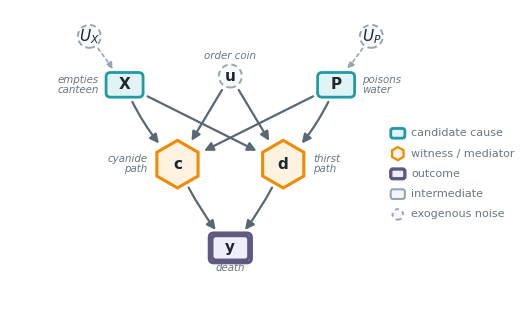

In [2]:
# Causal DAG for the desert-traveller model.
#
# Rendered with the SAME helper that generates the paper figure
# (scripts/make_example_dags.py): single source of truth, so this notebook and
# the paper never drift. The rendering is colour-blind-safe -- each role is
# encoded by SHAPE (box / hexagon / double box / dashed circle) as well as
# colour, and dashed U-circles mark the exogenous noise on each stochastic
# mechanism.
import pathlib
import sys

_p = pathlib.Path.cwd()
for _ in range(8):
    if (_p / "scripts" / "make_example_dags.py").exists():
        sys.path.insert(0, str(_p))
        break
    _p = _p.parent
from scripts.make_example_dags import fig_desert  # noqa: E402

fig, ax = plt.subplots(figsize=(5.8, 4.6))
ax.axis("off")
ax.set_aspect("equal")
fig_desert(ax)
plt.show()

In [3]:
def desert_eqs(X, P, u, c_pin=None, d_pin=None):
    c = c_pin if c_pin is not None else P * max(1 - u, 1 - X)
    d = d_pin if d_pin is not None else X * max(u, 1 - P)
    return c, d, max(c, d)


def dt_manual(cause, world_value, factual_mediators, Y_star):
    """PCI factor on the original DT under the spec above.

    - witness pool {c, d}; cardinality-uniform Gamma over k in {0, 1, 2}
    - non-cause suspect marginalised over Bern(0.5) -- follows the SCM, not pinned
    - noise u from prior Bern(0.5) -- we integrate, not condition
    - world_value = 0           -> necessity (do(C = alternative))
    - world_value = factual    -> sufficiency (do(C = factual))
    """
    f_c, f_d = factual_mediators
    subsets_by_k = {0: [("c", "d")], 1: [("d",), ("c",)], 2: [()]}
    weighted = 0.0
    total = 0.0
    for u in [0, 1]:
        p_u = 0.5
        for subsets in subsets_by_k.values():
            for w_set in subsets:
                prob_T = (1.0 / 3.0) / len(subsets)
                c_pin = f_c if "c" in w_set else None
                d_pin = f_d if "d" in w_set else None
                for other_val in [0, 1]:
                    X_int = world_value if cause == "X" else other_val
                    P_int = world_value if cause == "P" else other_val
                    _, _, Y = desert_eqs(X_int, P_int, u, c_pin=c_pin, d_pin=d_pin)
                    w = p_u * prob_T / 2
                    weighted += w * abs(Y - Y_star)
                    total += w
    return weighted / total

### One model per scenario

The coin $u$ decides which enemy's path operated, so it decides the answer.
Averaging over both orderings would blur the two cases into a single number, and
the question worth asking lives inside each one: given that cyanide killed him,
who is responsible? Given that dehydration killed him, who?

Forensic evidence settles $u$. Cyanide in the body and the timing put us in
Scenario A ($u = 0$); no cyanide and an empty canteen put us in Scenario B
($u = 1$). So we build one model per scenario, fix $u$ at that scenario's value,
and run the whole computation twice.

Two things should follow if PCI is doing its job. Pearl's beam analysis names the
enemy whose path operated as the actual cause and clears the other one, so PCI's
ranking should agree with it: poisoner above shooter in A, shooter above poisoner
in B. And PCI should decline to clear the dormant enemy outright, because
removing him does change the outcome in some of the witness configurations the
search sweeps. The figure below puts Pearl's verdict next to PCI's score so the
expectation and the finding can be read off together.

`ThinSearchSampler` scores each scenario, a hand-rolled enumeration scores it
again, and the printout puts the two side by side.

In [4]:
def make_dt_scenario_model(u_val):
    """Pyro model for the original DT with u pinned at u_val."""

    def _model(kwargs_iterable=None):
        if kwargs_iterable is None:
            kwargs_iterable = [{"observations_dict": None, "n_size": 1}, {}, {}]
        bs = kwargs_iterable[0]["n_size"]
        bl = torch.ones(bs, 1, 1, 2)
        u_tensor = torch.full((bs, 1, 1), u_val, dtype=torch.long)
        u = pyro.deterministic("u", u_tensor, event_dim=0)
        X = pyro.sample("X", dist.Categorical(logits=bl))
        P = pyro.sample("P", dist.Categorical(logits=bl))
        uf, Xf, Pf = u.float(), X.float(), P.float()
        c = pyro.deterministic("c", Pf * torch.maximum(1.0 - uf, 1.0 - Xf), event_dim=0)
        d = pyro.deterministic("d", Xf * torch.maximum(uf, 1.0 - Pf), event_dim=0)
        y = pyro.deterministic("y", torch.maximum(c, d), event_dim=0)
        return {
            "categorical": {"u": u, "X": X, "P": P},
            "continuous": {"c": c, "d": d, "y": y},
        }

    return _model


def make_dt_scenario_factual(u_val, c_val, d_val):
    return {
        "categorical": {
            "u": torch.tensor([[u_val]], dtype=torch.long).view(1, 1, 1),
            "X": torch.tensor([[1]], dtype=torch.long).view(1, 1, 1),
            "P": torch.tensor([[1]], dtype=torch.long).view(1, 1, 1),
        },
        "continuous": {
            "c": torch.tensor([[c_val]], dtype=torch.float).view(1, 1, 1),
            "d": torch.tensor([[d_val]], dtype=torch.float).view(1, 1, 1),
            "y": torch.tensor([[1.0]], dtype=torch.float).view(1, 1, 1),
        },
    }


def dt_manual_with_noise(cause, world_value, factual_mediators, Y_star, u_val):
    """DT PCI factor with u pinned at u_val. Non-cause suspect marginalised;
    cardinality-uniform Gamma over witness subsets of {c, d}."""
    f_c, f_d = factual_mediators
    subsets_by_k = {0: [("c", "d")], 1: [("d",), ("c",)], 2: [()]}
    weighted, total = 0.0, 0.0
    for subsets in subsets_by_k.values():
        for w_set in subsets:
            prob_T = (1.0 / 3.0) / len(subsets)
            c_pin = f_c if "c" in w_set else None
            d_pin = f_d if "d" in w_set else None
            for other_val in [0, 1]:
                X_int = world_value if cause == "X" else other_val
                P_int = world_value if cause == "P" else other_val
                _, _, Y = desert_eqs(X_int, P_int, u_val, c_pin=c_pin, d_pin=d_pin)
                w = prob_T / 2
                weighted += w * abs(Y - Y_star)
                total += w
    return weighted / total


def dt_joint_manual_with_noise(
    cause, factual_mediators, Y_star, factual_cause_value, u_val
):
    f_c, f_d = factual_mediators
    subsets_by_k = {0: [("c", "d")], 1: [("d",), ("c",)], 2: [()]}
    joint, total = 0.0, 0.0
    for subsets in subsets_by_k.values():
        for w_set in subsets:
            prob_T = (1.0 / 3.0) / len(subsets)
            c_pin = f_c if "c" in w_set else None
            d_pin = f_d if "d" in w_set else None
            p_s = 0.0
            for o in [0, 1]:
                X_int = factual_cause_value if cause == "X" else o
                P_int = factual_cause_value if cause == "P" else o
                _, _, Y_s = desert_eqs(X_int, P_int, u_val, c_pin=c_pin, d_pin=d_pin)
                p_s += 0.5 * (1.0 if Y_s == Y_star else 0.0)
            p_n = 0.0
            for o in [0, 1]:
                X_int = 0 if cause == "X" else o
                P_int = 0 if cause == "P" else o
                _, _, Y_n = desert_eqs(X_int, P_int, u_val, c_pin=c_pin, d_pin=d_pin)
                p_n += 0.5 * (1.0 if Y_n != Y_star else 0.0)
            joint += prob_T * p_s * p_n
            total += prob_T
    return joint / total


dt_scenario_specs = [
    ("A: cyanide killed", 0, 1.0, 0.0),
    ("B: dehydration killed", 1, 0.0, 1.0),
]

dt_forensic_framework_rows = []
dt_forensic_manual_rows = []
for label, u_val, c_val, d_val in dt_scenario_specs:
    scen_model = make_dt_scenario_model(u_val)
    scen_searchable = SearchableModel(
        structured_model=scen_model,
        sites_of_interest=["u", "X", "P", "c", "d", "y"],
        suspects=["X", "P"],
        deterministic_sites=["u", "c", "d", "y"],
        shared_noise_sites=[],
        outcome_variable="y",
        witness_sites=["c", "d"],
    )
    scen_sampler = ThinSearchSampler(
        structured_model=scen_searchable,
        conditioned_alternatives=False,
        factual_exclusion=True,
        max_antecedents=1,
        max_witnesses_dropped=2,
    )
    scen_fs = make_dt_scenario_factual(u_val, c_val, d_val)
    scen_results = scen_sampler.sample(scen_fs, num_samples=NUM_TS_SAMPLES)
    for cause_letter, cause_name in [("X", "shooter"), ("P", "poisoner")]:
        cond = condition_on_interventional_regime(
            results_dictionary=scen_results,  # type: ignore[arg-type]  # ThinSearchResult duck-types as dict
            reference_variable_names=[cause_letter],
            antecedent_regimes={cause_letter: True},
        )
        sc = abs_diff_score(
            factual_outcomes=scen_fs["continuous"]["y"],
            suff_outcomes=cond["regime_sufficiency"]["y"].detach(),
            nec_outcomes=cond["regime_necessity"]["y"].detach(),
        )
        N_f = sc["nec"][:, :, 0, 0].nanmean(dim=0).tolist()[0]
        S_f = 1.0 - abs(sc["suff"][:, :, 0, 0].nanmean(dim=0).tolist()[0])
        y_s = cond["regime_sufficiency"]["y"][:, 0, 0, 0].detach()
        y_n = cond["regime_necessity"]["y"][:, 0, 0, 0].detach()
        valid = ~(torch.isnan(y_s) | torch.isnan(y_n))
        J_f = ((y_s[valid] == 1.0).float() * (y_n[valid] != 1.0).float()).mean().item()
        dt_forensic_framework_rows.append(
            (label, cause_letter, cause_name, N_f, S_f, J_f)
        )
        # Manual
        N_m = dt_manual_with_noise(cause_letter, 0, (c_val, d_val), 1.0, u_val)
        S_m = 1.0 - dt_manual_with_noise(cause_letter, 1, (c_val, d_val), 1.0, u_val)
        J_m = dt_joint_manual_with_noise(cause_letter, (c_val, d_val), 1.0, 1, u_val)
        dt_forensic_manual_rows.append((label, cause_letter, cause_name, N_m, S_m, J_m))

print("Original DT, forensic-conditioned reading -- framework vs manual:")
print(
    f"{'Scenario':>26}  {'cause':>16}  {'N fwk':>8}  {'N man':>8}  {'S fwk':>8}  {'S man':>8}  {'J fwk':>8}  {'J man':>8}"
)
for fwk, man in zip(dt_forensic_framework_rows, dt_forensic_manual_rows):
    label, letter, name = fwk[0], fwk[1], fwk[2]
    label_cause = name + " (" + letter + ")"
    print(
        f"{label:>26}  {label_cause:>16}  "
        f"{fwk[3]:>8.4f}  {man[3]:>8.4f}  {fwk[4]:>8.4f}  {man[4]:>8.4f}  "
        f"{fwk[5]:>8.4f}  {man[5]:>8.4f}"
    )


# --- Sum-normalised share + per-cause "max-configuration" (best-witness) J ---
print()
print("Within-scenario J normalisation (each cause's share of joint attribution):")
print(f"{'Scenario':>26}  {'cause':>16}  {'J':>8}  {'share':>8}")
scenarios_seen: dict[str, list[tuple]] = {}
for row in dt_forensic_manual_rows:
    label = row[0]
    scenarios_seen.setdefault(label, []).append(row)
for label, rows in scenarios_seen.items():
    total = sum(r[5] for r in rows)
    for r in rows:
        label_cause = r[2] + " (" + r[1] + ")"
        share = r[5] / total if total > 0 else 0
        print(f"{label:>26}  {label_cause:>16}  {r[5]:>8.4f}  {share:>8.2%}")

# Per-witness maximum J for each cause (across the four witness subsets)
print()
print("Per-cause max-configuration J (best witness in this scenario):")
print(
    f"{'Scenario':>26}  {'cause':>16}  {'J avg':>8}  {'J max-cfg':>10}  {'avg/max':>8}"
)
subsets_list = [(), ("c",), ("d",), ("c", "d")]
for label, u_val, c_val, d_val in dt_scenario_specs:
    for cause_letter, cause_name in [("X", "shooter"), ("P", "poisoner")]:
        # Find J_avg (already in dt_forensic_manual_rows)
        J_avg = next(
            r[5]
            for r in dt_forensic_manual_rows
            if r[0] == label and r[1] == cause_letter
        )
        # Compute per-T joint
        per_T = []
        for w_set in subsets_list:
            c_pin = c_val if "c" in w_set else None
            d_pin = d_val if "d" in w_set else None
            p_s, p_n = 0.0, 0.0
            for o in [0, 1]:
                X_s = 1 if cause_letter == "X" else o
                P_s = 1 if cause_letter == "P" else o
                _, _, Ys = desert_eqs(X_s, P_s, u_val, c_pin=c_pin, d_pin=d_pin)
                p_s += 0.5 * (1.0 if Ys == 1 else 0.0)
                X_n = 0 if cause_letter == "X" else o
                P_n = 0 if cause_letter == "P" else o
                _, _, Yn = desert_eqs(X_n, P_n, u_val, c_pin=c_pin, d_pin=d_pin)
                p_n += 0.5 * (1.0 if Yn != 1 else 0.0)
            per_T.append(p_s * p_n)
        J_max = max(per_T)
        ratio = J_avg / J_max if J_max > 0 else 0
        label_cause = cause_name + " (" + cause_letter + ")"
        print(
            f"{label:>26}  {label_cause:>16}  {J_avg:>8.4f}  {J_max:>10.4f}  {ratio:>8.2%}"
        )

  0%|          | 0/8000 [00:00<?, ?it/s]

  1%|          | 90/8000 [00:00<00:08, 895.17it/s]

  2%|▏         | 183/8000 [00:00<00:08, 909.47it/s]

  3%|▎         | 278/8000 [00:00<00:08, 927.24it/s]

  5%|▍         | 376/8000 [00:00<00:08, 946.42it/s]

...

 97%|█████████▋| 7750/8000 [00:08<00:00, 909.99it/s]

 98%|█████████▊| 7844/8000 [00:08<00:00, 918.13it/s]

 99%|█████████▉| 7938/8000 [00:08<00:00, 924.26it/s]

100%|██████████| 8000/8000 [00:08<00:00, 929.02it/s]

Original DT, forensic-conditioned reading -- framework vs manual:
                  Scenario             cause     N fwk     N man     S fwk     S man     J fwk     J man
         A: cyanide killed       shooter (X)    0.2696    0.2500    0.9113    0.9167    0.2234    0.2083
         A: cyanide killed      poisoner (P)    0.3348    0.3333    1.0000    1.0000    0.3348    0.3333
     B: dehydration killed       shooter (X)    0.3241    0.3333    1.0000    1.0000    0.3241    0.3333
     B: dehydration killed      poisoner (P)    0.2537    0.2500    0.9077    0.9167    0.2091    0.2083

Within-scenario J normalisation (each cause's share of joint attribution):
                  Scenario             cause         J     share
         A: cyanide killed       shooter (X)    0.2083    38.46%
         A: cyanide killed      poisoner (P)    0.3333    61.54%
     B: dehydration killed       shooter (X)    0.3333    61.54%
     B: dehydration killed      poisoner (P)    0.2083    38.46%

Per-cau

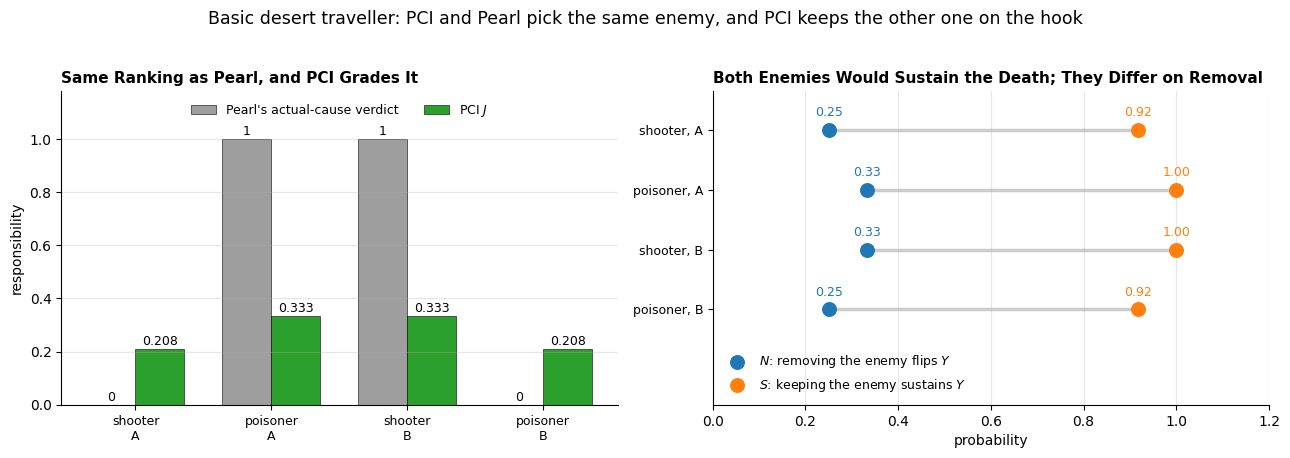

In [5]:
# Left: Pearl's one bit per cause against PCI's number. Right: the two factors
# PCI multiplies to get that number, on one axis so their gap is visible.


def plot_pci_vs_pearl(rows, headline):
    """rows are (scenario label, cause letter, cause name, N, S, J)."""
    labels = [f"{name}\n{label.split(':')[0]}" for label, _, name, *_ in rows]
    N = [r[3] for r in rows]
    S = [r[4] for r in rows]
    J = [r[5] for r in rows]
    # Pearl's beam analysis: the enemy whose path operated is the actual cause,
    # the other one is not. Scenario A is the cyanide scenario, B dehydration.
    pearl = [
        1.0 if (("cyanide" in label) == (letter == "P")) else 0.0
        for label, letter, *_ in rows
    ]

    x = np.arange(len(rows))
    w = 0.36
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.4))

    def annotate(ax, xs, vals, fmt="{:.3f}"):
        for xi, v in zip(xs, vals):
            ax.annotate(
                fmt.format(v),
                xy=(xi, v),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                fontsize=9,
            )

    axs[0].bar(
        x - w / 2,
        pearl,
        w,
        color="#9e9e9e",
        edgecolor="black",
        linewidth=0.4,
        label=r"Pearl's actual-cause verdict",
    )
    axs[0].bar(
        x + w / 2,
        J,
        w,
        color="#2ca02c",
        edgecolor="black",
        linewidth=0.4,
        label=r"PCI $J$",
    )
    annotate(axs[0], x - w / 2, pearl, "{:.0f}")
    annotate(axs[0], x + w / 2, J)
    axs[0].set_ylim(0, 1.18)
    axs[0].set_ylabel("responsibility")
    axs[0].set_title(
        "Same Ranking as Pearl, and PCI Grades It",
        loc="left",
        fontweight="bold",
        fontsize=11,
    )
    axs[0].legend(frameon=False, fontsize=9, loc="upper center", ncol=2)

    order = np.arange(len(rows))[::-1]
    for yi, n_, s_ in zip(order, N, S):
        axs[1].plot([n_, s_], [yi, yi], color="#cccccc", linewidth=2.5, zorder=1)
    axs[1].scatter(
        N,
        order,
        s=95,
        color="#1f77b4",
        zorder=3,
        label=r"$N$: removing the enemy flips $Y$",
    )
    axs[1].scatter(
        S,
        order,
        s=95,
        color="#ff7f0e",
        zorder=3,
        label=r"$S$: keeping the enemy sustains $Y$",
    )
    for yi, n_, s_ in zip(order, N, S):
        axs[1].annotate(
            f"{n_:.2f}",
            (n_, yi),
            xytext=(0, 10),
            fontsize=9,
            textcoords="offset points",
            ha="center",
            color="#1f77b4",
        )
        axs[1].annotate(
            f"{s_:.2f}",
            (s_, yi),
            xytext=(0, 10),
            fontsize=9,
            textcoords="offset points",
            ha="center",
            color="#ff7f0e",
        )
    axs[1].set_yticks(order)
    axs[1].set_yticklabels([lb.replace("\n", ", ") for lb in labels], fontsize=9)
    axs[1].set_xlim(0, 1.2)
    axs[1].set_ylim(-1.6, len(rows) - 0.35)
    axs[1].set_xlabel("probability")
    axs[1].set_title(
        "Both Enemies Would Sustain the Death; They Differ on Removal",
        loc="left",
        fontweight="bold",
        fontsize=11,
    )
    axs[1].legend(frameon=False, fontsize=9, loc="lower left", ncol=1)

    axs[0].set_xticks(x)
    axs[0].set_xticklabels(labels, fontsize=9)
    axs[0].grid(axis="y", alpha=0.3)
    axs[1].grid(axis="x", alpha=0.3)
    for ax in axs:
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)

    fig.suptitle(headline, fontsize=12.5, y=1.03)
    plt.tight_layout()
    plt.show()


plot_pci_vs_pearl(
    dt_forensic_manual_rows,
    "Basic desert traveller: PCI and Pearl pick the same enemy, "
    "and PCI keeps the other one on the hook",
)

Framework and manual agree on all three quantities within Monte Carlo noise, and PCI's
joint responsibility points to the operative cause in each scenario:

| Scenario | $J_{\text{shooter}}$ | $J_{\text{poisoner}}$ | Verdict |
|---|---|---|---|
| A: cyanide killed | $5/24 \approx 0.21$ | $\mathbf{1/3 \approx 0.33}$ | poisoner |
| B: dehydration killed | $\mathbf{1/3 \approx 0.33}$ | $5/24 \approx 0.21$ | shooter |

Two numbers in that table look odd at first, and they have the same explanation.

The poisoner in A did the killing, so why does he score $0.33$ and not $1$? The score
averages over witness sets, and only one of the four does the job cleanly. Pin the
dehydration mediator at its factual value, and removing the poisoner flips the outcome
every time while keeping him sustains it: that setup scores a full $1$, and it carries a
sixth of the averaging weight. The empty witness set scores $0.5$ and carries a third.
Together they make the $0.33$. The two setups that pin the cyanide mediator score
nothing at all, because pinning it holds the death in place whatever the poisoner does.

Why is the shooter above zero, when cyanide did the killing? With the coin at $u = 0$
and the model free to draw the poisoner's action, it sometimes draws a world in which
the poisoner never acted. Removing the shooter flips the outcome in those worlds, and
that earns him $0.21$ against the poisoner's $0.33$, about $38\%$ of the blame.

The ranking comes out as intended in both scenarios. 

## 3. Weak-poison variant

Both paths kill with certainty in the basic case, so Pearl and PCI cannot disagree
there: whatever ranking one of them produces, the other produces too. The variant breaks
that symmetry by making the cyanide unreliable, killing only when a coin comes up, while
dehydration stays as certain as before.

Pearl still returns $1$ for the operative enemy in each scenario, exactly as in the
basic case, whereas PCI now scores the poisoner in Scenario A at $0.21$ and the shooter
in Scenario B at $0.50$, so two cases Pearl cannot tell apart come apart under PCI. The
reading after the figure traces that to the dormant enemy.

The model is one addition away from the basic one: a fatality coin
$\xi \sim \mathrm{Bern}(\alpha)$ with $\alpha = 0.1$ now gates the cyanide path,

$$c = P (u' \vee X'), \quad v_C = c \cdot \xi, \quad
  d = X (u \vee P'), \quad y = v_C \vee d,$$

where $c$ still records that the traveller drank the poisoned water, and the new
mediator $v_C$ records that the cyanide was fatal, since drinking it kills only when
$\xi$ also fires.

The observation is unchanged, $X = P = 1$ and $Y = 1$, but the forensics now have two
coins to settle. In Scenario A, where cyanide killed, they give $u = 0$ because the
traveller drank early and $v_C = 1$ because the post-mortem found cyanide, and since
$v_C = c \cdot \xi$ that forces $\xi = 1$, leaving factual mediators
$(c, v_C, d) = (1, 1, 0)$. In Scenario B, where dehydration killed, they give $u = 1$
because the canteen ran dry before he could drink, and with the cyanide path dormant
$v_C = 0$, so we take $\xi = 0$ as a representative point mass. One pyro model per
scenario pins $(u, \xi)$ at those values, and the framework and the manual enumeration
then run side by side on each.

In [6]:
ALPHA = 0.1


def weak_poison_eqs(X, P, u, xi, c_pin=None, d_pin=None, V_C_pin=None):
    c = c_pin if c_pin is not None else P * max(1 - u, 1 - X)
    d = d_pin if d_pin is not None else X * max(u, 1 - P)
    V_C = V_C_pin if V_C_pin is not None else c * xi
    return c, d, V_C, max(V_C, d)


def wp_manual(cause, world_value, factual_mediators, Y_star):
    """PCI factor on the weak-poison DT under the spec above.

    - witness pool {c, d, V_C}; cardinality-uniform Gamma over k in {0, 1, 2, 3}
    - non-cause suspect marginalised over Bern(0.5)
    - noise (u, xi) from priors Bern(0.5) x Bern(alpha) -- we integrate, not condition on Y
    """
    f_c, f_d, f_V_C = factual_mediators
    subsets_by_k = {
        0: [("c", "V_C", "d")],
        1: [("V_C", "d"), ("c", "d"), ("c", "V_C")],
        2: [("d",), ("V_C",), ("c",)],
        3: [()],
    }
    weighted = 0.0
    total = 0.0
    for u in [0, 1]:
        for xi in [0, 1]:
            p_noise = 0.5 * (ALPHA if xi == 1 else (1 - ALPHA))
            for subsets in subsets_by_k.values():
                for w_set in subsets:
                    prob_T = 0.25 / len(subsets)
                    c_pin = f_c if "c" in w_set else None
                    d_pin = f_d if "d" in w_set else None
                    V_C_pin = f_V_C if "V_C" in w_set else None
                    for other_val in [0, 1]:
                        X_int = world_value if cause == "X" else other_val
                        P_int = world_value if cause == "P" else other_val
                        _, _, _, Y = weak_poison_eqs(
                            X_int,
                            P_int,
                            u,
                            xi,
                            c_pin=c_pin,
                            d_pin=d_pin,
                            V_C_pin=V_C_pin,
                        )
                        w = p_noise * prob_T / 2
                        weighted += w * abs(Y - Y_star)
                        total += w
    return weighted / total

### One model per scenario

Two expectations this time. Within each scenario we expect the ranking the basic case
already gave, PCI putting the operative enemy above the dormant one; across scenarios we
expect the shooter in B to outscore the poisoner in A, since dehydration kills whenever
it operates whereas the cyanide path turns on a coin. The reading after the figure
confirms that ordering and traces it to the dormant enemy, to whether he can still
deliver the death once we take the operative one away.

Both posteriors stay upstream of the outcome. Each conditions on mediator-level
observations, cyanide in the body or its absence together with the temporal evidence,
all of which the SCM places above $Y$, and we never condition on $Y = 1$ itself, which
the paper rules out as the fully-conditional anti-pattern (sec3:330--336,
sec3:381--387).

In [7]:
# --- Scenario-specific framework runs with forensic-conditioned noise ---
# Build a pyro model per scenario that hard-codes the forensic noise realisation.
# Then run ThinSearchSampler separately, batch_size=1 per scenario.


def make_scenario_model(u_val, xi_val):
    """Return a pyro model where u and xi are fixed at the scenario's forensic
    realisation. All other roots (X, P) sample from priors as usual."""

    def _model(kwargs_iterable=None):
        if kwargs_iterable is None:
            kwargs_iterable = [{"observations_dict": None, "n_size": 1}, {}, {}]
        bs = kwargs_iterable[0]["n_size"]
        bl = torch.ones(bs, 1, 1, 2)
        # Forensic noise pinned: use deterministic sites with the forensic values
        u_tensor = torch.full((bs, 1, 1), u_val, dtype=torch.long)
        xi_tensor = torch.full((bs, 1, 1), xi_val, dtype=torch.long)
        u = pyro.deterministic("u", u_tensor, event_dim=0)
        xi = pyro.deterministic("xi", xi_tensor, event_dim=0)
        X = pyro.sample("X", dist.Categorical(logits=bl))
        P = pyro.sample("P", dist.Categorical(logits=bl))
        uf, Xf, Pf, xif = u.float(), X.float(), P.float(), xi.float()
        c = pyro.deterministic("c", Pf * torch.maximum(1.0 - uf, 1.0 - Xf), event_dim=0)
        V_C = pyro.deterministic("V_C", c * xif, event_dim=0)
        d = pyro.deterministic("d", Xf * torch.maximum(uf, 1.0 - Pf), event_dim=0)
        y = pyro.deterministic("y", torch.maximum(V_C, d), event_dim=0)
        return {
            "categorical": {"u": u, "X": X, "P": P, "xi": xi},
            "continuous": {"c": c, "V_C": V_C, "d": d, "y": y},
        }

    return _model


def make_scenario_factual(u_val, xi_val, c_val, V_C_val, d_val):
    return {
        "categorical": {
            "u": torch.tensor([[u_val]], dtype=torch.long).view(1, 1, 1),
            "X": torch.tensor([[1]], dtype=torch.long).view(1, 1, 1),
            "P": torch.tensor([[1]], dtype=torch.long).view(1, 1, 1),
            "xi": torch.tensor([[xi_val]], dtype=torch.long).view(1, 1, 1),
        },
        "continuous": {
            "c": torch.tensor([[c_val]], dtype=torch.float).view(1, 1, 1),
            "V_C": torch.tensor([[V_C_val]], dtype=torch.float).view(1, 1, 1),
            "d": torch.tensor([[d_val]], dtype=torch.float).view(1, 1, 1),
            "y": torch.tensor([[1.0]], dtype=torch.float).view(1, 1, 1),
        },
    }


# Build the two scenario-specific samplers
scenario_specs = [
    ("A: cyanide killed", 0, 1, 1.0, 1.0, 0.0),  # (u, xi, c, V_C, d)
    ("B: dehydration killed", 1, 0, 0.0, 0.0, 1.0),
]

forensic_framework_rows = []
for label, u_val, xi_val, c_val, V_C_val, d_val in scenario_specs:
    scen_model = make_scenario_model(u_val, xi_val)
    scen_searchable = SearchableModel(
        structured_model=scen_model,
        sites_of_interest=["u", "X", "P", "xi", "c", "V_C", "d", "y"],
        suspects=["X", "P"],
        deterministic_sites=[
            "u",
            "xi",
            "c",
            "V_C",
            "d",
            "y",
        ],  # u, xi are now deterministic too
        shared_noise_sites=[],  # noise already fixed in the model
        outcome_variable="y",
        witness_sites=["c", "V_C", "d"],
    )
    scen_sampler = ThinSearchSampler(
        structured_model=scen_searchable,
        conditioned_alternatives=False,
        factual_exclusion=True,
        max_antecedents=1,
        max_witnesses_dropped=3,
    )
    scen_fs = make_scenario_factual(u_val, xi_val, c_val, V_C_val, d_val)
    scen_results = scen_sampler.sample(scen_fs, num_samples=NUM_TS_SAMPLES)
    for cause_letter, cause_name in [("X", "shooter"), ("P", "poisoner")]:
        cond = condition_on_interventional_regime(
            results_dictionary=scen_results,  # type: ignore[arg-type]  # ThinSearchResult duck-types as dict
            reference_variable_names=[cause_letter],
            antecedent_regimes={cause_letter: True},
        )
        sc = abs_diff_score(
            factual_outcomes=scen_fs["continuous"]["y"],
            suff_outcomes=cond["regime_sufficiency"]["y"].detach(),
            nec_outcomes=cond["regime_necessity"]["y"].detach(),
        )
        N_f = sc["nec"][:, :, 0, 0].nanmean(dim=0).tolist()[0]
        S_f = 1.0 - abs(sc["suff"][:, :, 0, 0].nanmean(dim=0).tolist()[0])
        y_s = cond["regime_sufficiency"]["y"][:, 0, 0, 0].detach()
        y_n = cond["regime_necessity"]["y"][:, 0, 0, 0].detach()
        valid = ~(torch.isnan(y_s) | torch.isnan(y_n))
        J_f = ((y_s[valid] == 1.0).float() * (y_n[valid] != 1.0).float()).mean().item()
        forensic_framework_rows.append((label, cause_letter, cause_name, N_f, S_f, J_f))


# --- Manual under same forensic conditioning ---
def wp_manual_with_noise(cause, world_value, factual_mediators, Y_star, noise_dist):
    f_c, f_d, f_V_C = factual_mediators
    subsets_by_k = {
        0: [("c", "V_C", "d")],
        1: [("V_C", "d"), ("c", "d"), ("c", "V_C")],
        2: [("d",), ("V_C",), ("c",)],
        3: [()],
    }
    weighted, total = 0.0, 0.0
    for noise_tuple, p_noise in noise_dist:
        u, xi = noise_tuple
        for subsets in subsets_by_k.values():
            for w_set in subsets:
                prob_T = 0.25 / len(subsets)
                c_pin = f_c if "c" in w_set else None
                d_pin = f_d if "d" in w_set else None
                V_C_pin = f_V_C if "V_C" in w_set else None
                for other_val in [0, 1]:
                    X_int = world_value if cause == "X" else other_val
                    P_int = world_value if cause == "P" else other_val
                    _, _, _, Y = weak_poison_eqs(
                        X_int,
                        P_int,
                        u,
                        xi,
                        c_pin=c_pin,
                        d_pin=d_pin,
                        V_C_pin=V_C_pin,
                    )
                    w = p_noise * prob_T / 2
                    weighted += w * abs(Y - Y_star)
                    total += w
    return weighted / total


def wp_joint_with_noise(
    cause, factual_mediators, Y_star, factual_cause_value, noise_dist
):
    f_c, f_d, f_V_C = factual_mediators
    subsets_by_k = {
        0: [("c", "V_C", "d")],
        1: [("V_C", "d"), ("c", "d"), ("c", "V_C")],
        2: [("d",), ("V_C",), ("c",)],
        3: [()],
    }
    joint, total = 0.0, 0.0
    for noise_tuple, p_noise in noise_dist:
        u, xi = noise_tuple
        for subsets in subsets_by_k.values():
            for w_set in subsets:
                prob_T = 0.25 / len(subsets)
                c_pin = f_c if "c" in w_set else None
                d_pin = f_d if "d" in w_set else None
                V_C_pin = f_V_C if "V_C" in w_set else None
                p_s = 0.0
                for o in [0, 1]:
                    X_int = factual_cause_value if cause == "X" else o
                    P_int = factual_cause_value if cause == "P" else o
                    _, _, _, Y_s = weak_poison_eqs(
                        X_int, P_int, u, xi, c_pin=c_pin, d_pin=d_pin, V_C_pin=V_C_pin
                    )
                    p_s += 0.5 * (1.0 if Y_s == Y_star else 0.0)
                p_n = 0.0
                for o in [0, 1]:
                    X_int = 0 if cause == "X" else o
                    P_int = 0 if cause == "P" else o
                    _, _, _, Y_n = weak_poison_eqs(
                        X_int, P_int, u, xi, c_pin=c_pin, d_pin=d_pin, V_C_pin=V_C_pin
                    )
                    p_n += 0.5 * (1.0 if Y_n != Y_star else 0.0)
                joint += p_noise * prob_T * p_s * p_n
                total += p_noise * prob_T
    return joint / total


forensic_A_dist = [((0, 1), 1.0)]  # Scenario A forensic: u=0, xi=1
forensic_B_dist = [((1, 0), 1.0)]  # Scenario B forensic: u=1, xi=0

forensic_manual_rows = []
for label, fmed, noise in [
    ("A: cyanide killed", (1.0, 0.0, 1.0), forensic_A_dist),
    ("B: dehydration killed", (0.0, 1.0, 0.0), forensic_B_dist),
]:
    for cause_letter, cause_name in [("X", "shooter"), ("P", "poisoner")]:
        N = wp_manual_with_noise(cause_letter, 0, fmed, 1.0, noise)
        S = 1.0 - wp_manual_with_noise(cause_letter, 1, fmed, 1.0, noise)
        J = wp_joint_with_noise(cause_letter, fmed, 1.0, 1, noise)
        forensic_manual_rows.append((label, cause_letter, cause_name, N, S, J))


# --- Print comparison ---
print("Per-scenario reading (forensic-conditioned noise) -- framework vs manual:")
print(
    f"{'Scenario':>26}  {'cause':>16}  {'N fwk':>8}  {'N man':>8}  {'S fwk':>8}  {'S man':>8}  {'J fwk':>8}  {'J man':>8}"
)
for fwk, man in zip(forensic_framework_rows, forensic_manual_rows):
    assert fwk[0] == man[0] and fwk[1] == man[1]
    label, letter, name = fwk[0], fwk[1], fwk[2]
    label_cause = name + " (" + letter + ")"
    print(
        f"{label:>26}  {label_cause:>16}  "
        f"{fwk[3]:>8.4f}  {man[3]:>8.4f}  {fwk[4]:>8.4f}  {man[4]:>8.4f}  "
        f"{fwk[5]:>8.4f}  {man[5]:>8.4f}"
    )


# --- Sum-normalised share + per-cause max-configuration J ---
print()
print("Within-scenario J normalisation (each cause's share of joint attribution):")
print(f"{'Scenario':>26}  {'cause':>16}  {'J':>8}  {'share':>8}")
scenarios_seen_wp: dict[str, list[tuple]] = {}
for row in forensic_manual_rows:
    scenarios_seen_wp.setdefault(row[0], []).append(row)
for label, rows in scenarios_seen_wp.items():
    total = sum(r[5] for r in rows)
    for r in rows:
        label_cause = r[2] + " (" + r[1] + ")"
        share = r[5] / total if total > 0 else 0
        print(f"{label:>26}  {label_cause:>16}  {r[5]:>8.4f}  {share:>8.2%}")

# Per-cause max-configuration J (best-witness ratio) for weak-poison
print()
print("Per-cause max-configuration J (best witness in this scenario):")
print(
    f"{'Scenario':>26}  {'cause':>16}  {'J avg':>8}  {'J max-cfg':>10}  {'avg/max':>8}"
)
wp_subsets_list = []
import itertools as _it

for r in range(0, 4):  # type: ignore[assignment]  # loop counter reuses tuple-typed name r
    wp_subsets_list.extend(_it.combinations(["c", "d", "V_C"], r))  # type: ignore[call-overload]  # r is int at runtime
for label, fmed, noise in [
    ("A: cyanide killed", (1.0, 0.0, 1.0), forensic_A_dist),
    ("B: dehydration killed", (0.0, 1.0, 0.0), forensic_B_dist),
]:
    f_c, f_d, f_V_C = fmed
    for cause_letter, cause_name in [("X", "shooter"), ("P", "poisoner")]:
        J_avg = next(
            r[5] for r in forensic_manual_rows if r[0] == label and r[1] == cause_letter
        )
        per_T = []
        for w_set in wp_subsets_list:
            c_pin = f_c if "c" in w_set else None
            d_pin = f_d if "d" in w_set else None
            V_C_pin = f_V_C if "V_C" in w_set else None
            for noise_tuple, p_noise in noise:
                u, xi = noise_tuple
                p_s, p_n = 0.0, 0.0
                for o in [0, 1]:
                    X_s = 1 if cause_letter == "X" else o
                    P_s = 1 if cause_letter == "P" else o
                    _, _, _, Ys = weak_poison_eqs(
                        X_s, P_s, u, xi, c_pin=c_pin, d_pin=d_pin, V_C_pin=V_C_pin
                    )
                    p_s += 0.5 * (1.0 if Ys == 1 else 0.0)
                    X_n = 0 if cause_letter == "X" else o
                    P_n = 0 if cause_letter == "P" else o
                    _, _, _, Yn = weak_poison_eqs(
                        X_n, P_n, u, xi, c_pin=c_pin, d_pin=d_pin, V_C_pin=V_C_pin
                    )
                    p_n += 0.5 * (1.0 if Yn != 1 else 0.0)
                per_T.append(p_noise * p_s * p_n)
        # max here is over witness subsets after summing noise contribution
        # (per_T entries are per (T, noise_state) so we group by T)
        # since each T appears in multiple noise rows, sum per T
        # rebuild grouped by T
        per_T_grouped = []
        for w_set in wp_subsets_list:
            c_pin = f_c if "c" in w_set else None
            d_pin = f_d if "d" in w_set else None
            V_C_pin = f_V_C if "V_C" in w_set else None
            joint_at_T = 0.0
            for noise_tuple, p_noise in noise:
                u, xi = noise_tuple
                p_s, p_n = 0.0, 0.0
                for o in [0, 1]:
                    X_s = 1 if cause_letter == "X" else o
                    P_s = 1 if cause_letter == "P" else o
                    _, _, _, Ys = weak_poison_eqs(
                        X_s, P_s, u, xi, c_pin=c_pin, d_pin=d_pin, V_C_pin=V_C_pin
                    )
                    p_s += 0.5 * (1.0 if Ys == 1 else 0.0)
                    X_n = 0 if cause_letter == "X" else o
                    P_n = 0 if cause_letter == "P" else o
                    _, _, _, Yn = weak_poison_eqs(
                        X_n, P_n, u, xi, c_pin=c_pin, d_pin=d_pin, V_C_pin=V_C_pin
                    )
                    p_n += 0.5 * (1.0 if Yn != 1 else 0.0)
                joint_at_T += p_noise * p_s * p_n
            per_T_grouped.append(joint_at_T)
        J_max = max(per_T_grouped)
        ratio = J_avg / J_max if J_max > 0 else 0
        label_cause = cause_name + " (" + cause_letter + ")"
        print(
            f"{label:>26}  {label_cause:>16}  {J_avg:>8.4f}  {J_max:>10.4f}  {ratio:>8.2%}"
        )

  0%|          | 0/8000 [00:00<?, ?it/s]

  1%|          | 85/8000 [00:00<00:09, 843.85it/s]

  2%|▏         | 170/8000 [00:00<00:09, 838.49it/s]

  3%|▎         | 256/8000 [00:00<00:09, 843.64it/s]

  4%|▍         | 342/8000 [00:00<00:09, 846.42it/s]

...

 97%|█████████▋| 7788/8000 [00:09<00:00, 819.97it/s]

 98%|█████████▊| 7871/8000 [00:09<00:00, 821.79it/s]

 99%|█████████▉| 7954/8000 [00:09<00:00, 822.28it/s]

100%|██████████| 8000/8000 [00:09<00:00, 813.56it/s]

Per-scenario reading (forensic-conditioned noise) -- framework vs manual:
                  Scenario             cause     N fwk     N man     S fwk     S man     J fwk     J man
         A: cyanide killed       shooter (X)    0.1629    0.1667    0.9598    0.9583    0.1457    0.1458
         A: cyanide killed      poisoner (P)    0.2103    0.2083    1.0000    1.0000    0.2103    0.2083
     B: dehydration killed       shooter (X)    0.4731    0.5000    1.0000    1.0000    0.4731    0.5000
     B: dehydration killed      poisoner (P)    0.2619    0.2500    0.7484    0.7500    0.1303    0.1250

Within-scenario J normalisation (each cause's share of joint attribution):
                  Scenario             cause         J     share
         A: cyanide killed       shooter (X)    0.1458    41.18%
         A: cyanide killed      poisoner (P)    0.2083    58.82%
     B: dehydration killed       shooter (X)    0.5000    80.00%
     B: dehydration killed      poisoner (P)    0.1250    20.00%


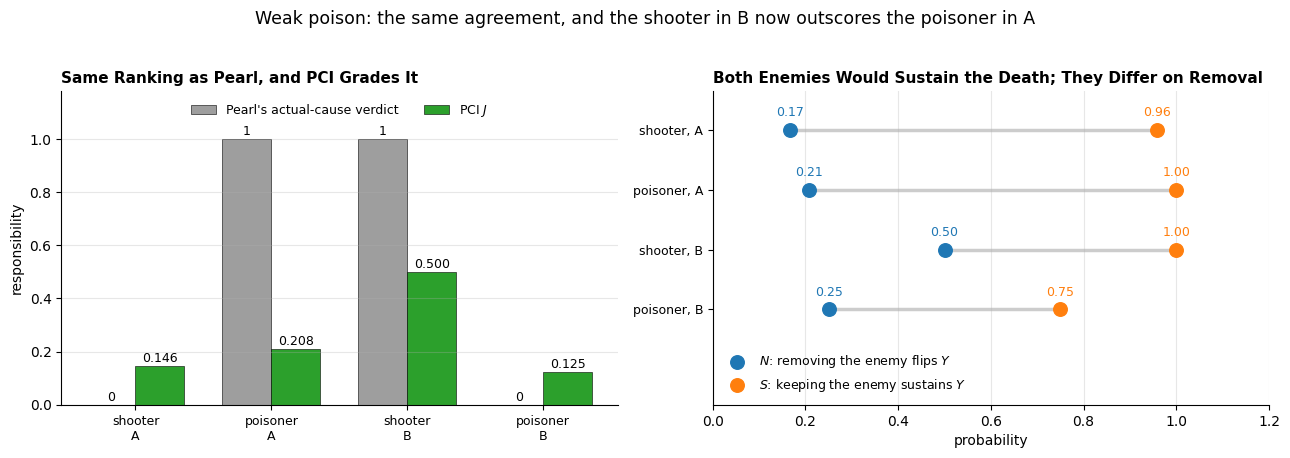

In [8]:
plot_pci_vs_pearl(
    forensic_manual_rows,
    "Weak poison: the same agreement, and the shooter in B now outscores "
    "the poisoner in A",
)

Framework and manual agree again, and the joint score again points to the operative
cause in each scenario:

| Scenario | $J_{\text{shooter}}$ | $J_{\text{poisoner}}$ | Verdict |
|---|---|---|---|
| A: cyanide killed | $\approx 0.146$ | $\mathbf{\approx 0.208}$ | poisoner |
| B: dehydration killed | $\mathbf{\approx 0.500}$ | $\approx 0.125$ | shooter |

One question carries over from the basic case, and a second one is new.

Why is the poisoner in A down at $0.21$? The same averaging as before, with one more
mediator in the witness pool. Only the setup pinning the dehydration mediator scores a
full $1$, and with eight setups to spread across it now carries a twelfth of the weight
instead of a sixth. Most of his $0.21$ comes from the empty witness set, at $0.5$.

Why does the shooter in B score more than twice as much, $0.50$, when each enemy is the
killer in his own scenario? Because the other enemy can still deliver the death in one
scenario and not in the other. In B the
fatality coin came up $\xi = 0$, so the cyanide path is dead: take the shooter away and
nothing remains that can kill, and the outcome flips in every setup that leaves the path
open. Four of the eight setups score a full $1$. In A the shooter is still standing with
a working dehydration path, so taking the poisoner away lets the shooter cover the death
half the time, and only one setup reaches $1$.

The fatality coin therefore does not lower the ceiling. Both operative causes touch $1$
somewhere. The coin removes the other configurations that would have reached it.